In [ ]:
import os
import pandas as pd
import numpy as np

conds = {
    "CD": "sparcc_CD",
    "UC": "sparcc_UC",
    "Healthy": "sparcc_Healthy"
}

for cond, folder in conds.items():
    cor = f"../data/processed/{folder}/cor_{cond}.csv"
    pval = f"../data/processed/{folder}/pvals_{cond}.csv"

    c_ok = os.path.exists(cor)
    p_ok = os.path.exists(pval)

    print(f"{cond}: cor={'yes' if c_ok else 'no'}  pval={'yes' if p_ok else 'no'}")

CD: cor=yes  pval=yes
UC: cor=yes  pval=yes
Healthy: cor=yes  pval=yes


In [ ]:
import pandas as pd
import numpy as np
import os

def load_matrix(path):
    df = pd.read_csv(path, sep='\t', index_col=0)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df.index   = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()

    all_species = sorted(set(df.index) | set(df.columns))
    df = df.reindex(index=all_species, columns=all_species, fill_value=0)

    return df

def filter_and_clean(cor_path, pval_path, condition):
    print(f"\n{condition}")

    cor  = load_matrix(cor_path)
    pval = load_matrix(pval_path)

    print("Shape:", cor.shape)

    pval = pval.apply(pd.to_numeric, errors='coerce').fillna(1.0)
    cor  = cor.apply(pd.to_numeric, errors='coerce')

    cor  = (cor + cor.T) / 2
    pval = (pval + pval.T) / 2

    np.fill_diagonal(cor.values,  0)
    np.fill_diagonal(pval.values, 1)

    out_dir = f"../data/processed/sparcc_{condition}"
    os.makedirs(out_dir, exist_ok=True)
    cor.to_csv(f"{out_dir}/cor_{condition}_clean.csv")
    pval.to_csv(f"{out_dir}/pvals_{condition}_clean.csv")

    print(f"Saved clean files")
    return cor, pval

results = {}

for cond in ["CD", "UC", "Healthy"]:
    cor, pval = filter_and_clean(
        f"../data/processed/sparcc_{cond}/cor_{cond}.csv",
        f"../data/processed/sparcc_{cond}/pvals_{cond}.csv",
        cond
    )
    results[cond] = {"cor": cor, "pval": pval}


CD
Shape: (87, 87)
Saved clean files

UC
Shape: (87, 87)
Saved clean files

Healthy
Shape: (87, 87)
Saved clean files


In [ ]:
import os

for cond in ["CD", "UC", "Healthy"]:
    path = f"../data/processed/sparcc_{cond}"
    print("\n", cond)
    if os.path.exists(path):
        print(os.listdir(path))
    else:
        print("Folder missing:", path)


 CD
['cor_CD.csv', 'cor_CD_clean.csv', 'pvals_CD.csv', 'pvals_CD_clean.csv']

 UC
['cor_UC.csv', 'cor_UC_clean.csv', 'pvals_UC.csv', 'pvals_UC_clean.csv']

 Healthy
['cor_Healthy.csv', 'cor_Healthy_clean.csv', 'pvals_Healthy.csv', 'pvals_Healthy_clean.csv']


In [ ]:
print("Row names sample:", cor.index[:5])
print("Column names sample:", cor.columns[:5])

Row names sample: Index(['Akkermansia_muciniphila', 'Alistipes_finegoldii', 'Alistipes_onderdonkii', 'Alistipes_putredinis', 'Alistipes_shahii'], dtype='object', name='#OTU ID')
Column names sample: Index(['Akkermansia_muciniphila', 'Alistipes_finegoldii', 'Alistipes_onderdonkii', 'Alistipes_putredinis', 'Alistipes_shahii'], dtype='object')


In [ ]:
for cond in results:
    cor = results[cond]["cor"]
    print(cond, "symmetric:", np.allclose(cor, cor.T))

CD symmetric: True
UC symmetric: True
Healthy symmetric: True


In [ ]:
print("Edges at each threshold (|r| > thresh AND p < 0.05):")
print(f"{'Threshold':>10} {'CD':>10} {'UC':>10} {'Healthy':>10}")
print("-"*45)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

for thresh in thresholds:
    row = f"{thresh:>10.2f}"
    
    for cond in ['CD', 'UC', 'Healthy']:
        cor = results[cond]['cor']
        pval = results[cond]['pval']
        
        mask = (cor.abs() > thresh) & (pval < 0.05)
        n = mask.values.sum() // 2
        
        row += f"{n:>10}"
    
    print(row)


Edges at each threshold (|r| > thresh AND p < 0.05):
 Threshold         CD         UC    Healthy
---------------------------------------------
      0.05      2202      2037      2184
      0.10      1661      1853      2064
      0.15       956      1158      1399
      0.20       518       690       913
      0.25       257       414       577
      0.30       146       204       352


In [ ]:
import os
import pandas as pd
import networkx as nx

THRESHOLD = 0.15
PVAL_CUT = 0.05

os.makedirs("../results/networks", exist_ok=True)

def build_network(condition, threshold, pval_cutoff):

    cor_path = f"../data/processed/sparcc_{condition}/cor_{condition}_clean.csv"
    pval_path = f"../data/processed/sparcc_{condition}/pvals_{condition}_clean.csv"
    
    cor  = pd.read_csv(cor_path,  sep=',', index_col=0)
    pval = pd.read_csv(pval_path, sep=',', index_col=0)

    common = cor.index.intersection(cor.columns)
    cor = cor.loc[common, common]
    pval = pval.loc[common, common]

    G = nx.Graph()

    G.add_nodes_from(common)

    mut, comp = 0, 0

    for i in range(len(common)):
        for j in range(i + 1, len(common)):

            sp1, sp2 = common[i], common[j]
            r = cor.iloc[i, j]
            p = pval.iloc[i, j]

            if pd.isna(r) or pd.isna(p):
                continue

            if abs(r) > threshold and p < pval_cutoff:

                interaction = "mutualism" if r > 0 else "competition"

                G.add_edge(
                    sp1, sp2,
                    weight=float(abs(r)),
                    correlation=float(r),
                    interaction=interaction
                )

                if r > 0:
                    mut += 1
                else:
                    comp += 1

    print(f"\n{condition}")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print(f"  Mutualism: {mut}")
    print(f"  Competition: {comp}")
    print(f"Density: {nx.density(G):.6f}")

    G.remove_nodes_from(list(nx.isolates(G)))

    print(f"Nodes after removing isolates: {G.number_of_nodes()}")

    out_path = f"../results/networks/{condition}_network.gexf"
    nx.write_gexf(G, out_path)

    print(f"Saved: {out_path}")

    return G

networks = {}
for cond in ["CD", "UC", "Healthy"]:
    networks[cond] = build_network(cond, THRESHOLD, PVAL_CUT)


CD
Nodes: 87
Edges: 956
  Mutualism: 478
  Competition: 478
Density: 0.255547
Nodes after removing isolates: 87
Saved: ../results/networks/CD_network.gexf

UC
Nodes: 87
Edges: 1158
  Mutualism: 580
  Competition: 578
Density: 0.309543
Nodes after removing isolates: 87
Saved: ../results/networks/UC_network.gexf

Healthy
Nodes: 87
Edges: 1399
  Mutualism: 702
  Competition: 697
Density: 0.373964
Nodes after removing isolates: 87
Saved: ../results/networks/Healthy_network.gexf


In [ ]:
import os
import pandas as pd
import networkx as nx
from IPython.display import display
from networkx.algorithms.community import greedy_modularity_communities

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

os.makedirs("../results/networks", exist_ok=True)


def analyze_network(G, condition):
    print(f"\nRunning analysis for: {condition}")

    if G.number_of_edges() == 0:
        print(f"{condition}: No edges — lower threshold")
        return {}

    betweenness = nx.betweenness_centrality(G, weight='weight')
    degree = nx.degree_centrality(G)

    try:
        eigenvector = nx.eigenvector_centrality(
            G, weight='weight', max_iter=1000
        )
    except:
        print(f"{condition}: Eigenvector failed → using zeros")
        eigenvector = {n: 0 for n in G.nodes()}

    communities = list(greedy_modularity_communities(G))
    modularity = nx.algorithms.community.quality.modularity(G, communities)

    metrics = pd.DataFrame({
        'species': list(G.nodes()),
        'betweenness': [betweenness[n] for n in G.nodes()],
        'degree': [degree[n] for n in G.nodes()],
        'eigenvector': [eigenvector[n] for n in G.nodes()]
    })

    metrics['keystone_score'] = (
        0.5 * metrics['betweenness'] +
        0.3 * metrics['degree'] +
        0.2 * metrics['eigenvector']
    )

    metrics['condition'] = condition
    metrics = metrics.sort_values('keystone_score', ascending=False)

    save_path = f"../results/networks/keystones_{condition}.csv"
    metrics.to_csv(save_path, index=False)

    print(f"\n{condition}:")
    print(f"Modularity = {modularity:.3f}")
    print(f"Communities = {len(communities)}")

    print("\nTop 5 keystone species:")
    display(metrics[['species', 'keystone_score']].head(5))

    return {
        'condition': condition,
        'modularity': modularity,
        'n_communities': len(communities),
        'density': nx.density(G),
        'avg_clustering': nx.average_clustering(G),
        'n_nodes': G.number_of_nodes(),
        'n_edges': G.number_of_edges(),
        'n_mutualism': sum(
            1 for _, _, d in G.edges(data=True)
            if d.get('interaction') == 'mutualism'
        ),
        'n_competition': sum(
            1 for _, _, d in G.edges(data=True)
            if d.get('interaction') == 'competition'
        )
    }


net_metrics = {}

for cond, G in networks.items():
    result = analyze_network(G, cond)
    net_metrics[cond] = result
    print("\n" + "\n")


net_metrics_df = pd.DataFrame(net_metrics).T

print("\nFINAL NETWORK SUMMARY:")
display(net_metrics_df)

print("\nVerifying saved keystone files:")

for cond in networks.keys():
    path = f"../results/networks/keystones_{cond}.csv"
    print(f"\n{cond} (from file):")
    
    try:
        df = pd.read_csv(path)
        display(df[['species','keystone_score']].head(5))
    except:
        print("File not found or error reading file")


Running analysis for: CD

CD:
Modularity = 0.250
Communities = 4

Top 5 keystone species:


,species,keystone_score
43,Escherichia_coli,0.215460
29,Clostridium_bartlettii,0.212899
63,Odoribacter_splanchnicus,0.212309
32,Clostridium_clostridioforme,0.196498
3,Alistipes_putredinis,0.196438






Running analysis for: UC

UC:
Modularity = 0.174
Communities = 4

Top 5 keystone species:


,species,keystone_score
13,Bacteroides_ovatus,0.186430
86,Veillonella_unclassified,0.181346
23,Bilophila_unclassified,0.179387
16,Bacteroides_uniformis,0.178686
77,Ruminococcus_gnavus,0.178492






Running analysis for: Healthy

Healthy:
Modularity = 0.145
Communities = 3

Top 5 keystone species:


...

,species,keystone_score
0,Escherichia_coli,0.215460
1,Clostridium_bartlettii,0.212899
2,Odoribacter_splanchnicus,0.212309
3,Clostridium_clostridioforme,0.196498
4,Alistipes_putredinis,0.196438



UC (from file):


,species,keystone_score
0,Bacteroides_ovatus,0.186430
1,Veillonella_unclassified,0.181346
2,Bilophila_unclassified,0.179387
3,Bacteroides_uniformis,0.178686
4,Ruminococcus_gnavus,0.178492



Healthy (from file):


,species,keystone_score
0,Clostridium_symbiosum,0.241457
1,Ruminococcus_gnavus,0.229710
2,Clostridium_clostridioforme,0.226678
3,Barnesiella_intestinihominis,0.223957
4,Alistipes_onderdonkii,0.215739


In [ ]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


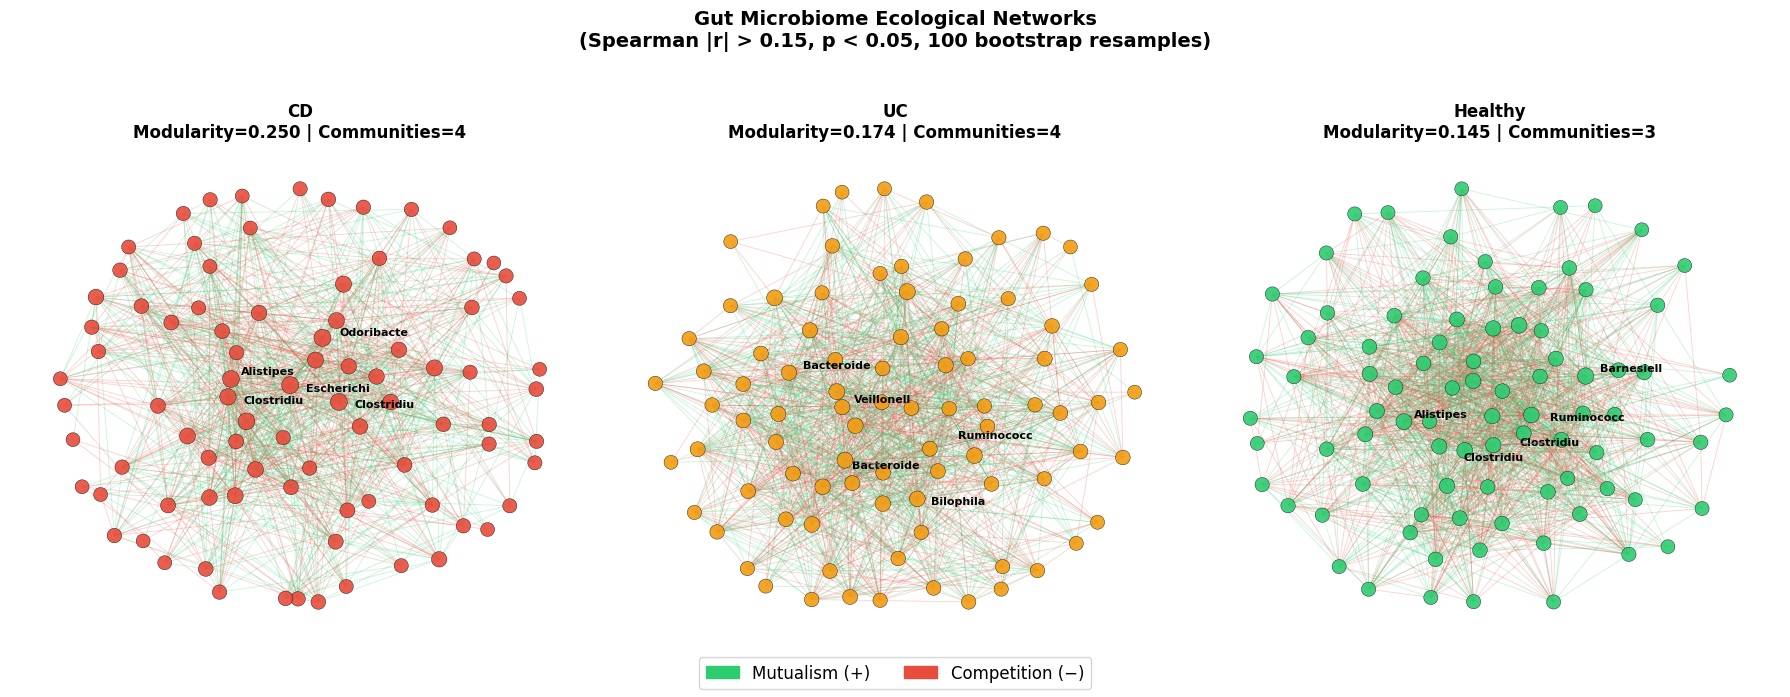

Figure saved at: ../figures/final/Fig2_networks.png


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import matplotlib.patches as mpatches
from adjustText import adjust_text

colors_map = {
    'CD': '#e74c3c',
    'UC': '#f39c12',
    'Healthy': '#2ecc71'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (cond, G) in zip(axes, networks.items()):

    if G.number_of_edges() == 0:
        ax.text(0.5, 0.5, f'{cond}\nNo edges',
                ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(cond)
        ax.axis('off')
        continue

    pos = nx.spring_layout(G, k=2.2, iterations=100, seed=42)

    edge_colors = [
        '#2ecc71' if G[u][v].get('interaction') == 'mutualism'
        else '#e74c3c'
        for u, v in G.edges()
    ]

    bet = nx.betweenness_centrality(G)
    node_sizes = [100 + 1500 * bet[n] for n in G.nodes()]

    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=colors_map.get(cond),
        edgecolors='black',
        linewidths=0.3,
        alpha=0.9,
        ax=ax
    )

    nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_colors,
        alpha=0.25,
        width=0.6,
        ax=ax
    )

    texts = []

    try:
        df = pd.read_csv(f"../results/networks/keystones_{cond}.csv")
        keystones = df.head(5)['species'].tolist()
    except:
        keystones = []

    for n in G.nodes():
        if n in keystones:
            x, y = pos[n]
            label = n.split('_')[0][:10]

            txt = ax.text(
                x, y,
                label,
                fontsize=8,
                fontweight='bold'
            )
            texts.append(txt)

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.3, 1.5),
        expand_text=(1.3, 1.5),
        force_text=1.0,
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.5,
            shrinkA=5,
            shrinkB=5
        ),
        only_move={'points': 'y', 'texts': 'xy'}
    )

    m = net_metrics.get(cond, {})

    ax.set_title(
        f"{cond}\n"
        f"Modularity={m.get('modularity',0):.3f} | "
        f"Communities={m.get('n_communities',0)}",
        fontweight='bold',
        fontsize=12
    )

    ax.axis('off')

green = mpatches.Patch(color='#2ecc71', label='Mutualism (+)')
red = mpatches.Patch(color='#e74c3c', label='Competition (−)')

fig.legend(
    handles=[green, red],
    loc='lower center',
    ncol=2,
    fontsize=12
)

plt.suptitle(
    f"Gut Microbiome Ecological Networks\n"
    f"(Spearman |r| > {THRESHOLD}, p < {PVAL_CUT}, "
    f"100 bootstrap resamples)",
    fontsize=14,
    fontweight='bold'
)

save_path = "../figures/final/Fig2_networks.png"

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved at: {save_path}")

In [ ]:
summary = pd.DataFrame([
    {
        'Condition': cond,
        'Nodes': networks[cond].number_of_nodes(),
        'Edges': networks[cond].number_of_edges(),
        'Mutualism': net_metrics.get(cond, {}).get('n_mutualism', 0),
        'Competition': net_metrics.get(cond, {}).get('n_competition', 0),
        'Modularity': round(net_metrics.get(cond, {}).get('modularity', 0), 3),
        'Communities': net_metrics.get(cond, {}).get('n_communities', 0),
        'Density': round(net_metrics.get(cond, {}).get('density', 0), 6)
    }
    for cond in ["CD", "UC", "Healthy"]
])

print("\nNETWORK SUMMARY (Table 1):\n")
print(summary.to_string(index=False))

save_path = "../results/networks/network_summary.csv"
summary.to_csv(save_path, index=False)

print(f"\nTable saved at: {save_path}")
print("Open ../results/networks/*.gexf in Gephi for visualization")


NETWORK SUMMARY (Table 1):

Condition  Nodes  Edges  Mutualism  Competition  Modularity  Communities  Density
       CD     87    956        478          478       0.250            4 0.255547
       UC     87   1158        580          578       0.174            4 0.309543
  Healthy     87   1399        702          697       0.145            3 0.373964

Table saved at: ../results/networks/network_summary.csv
Open ../results/networks/*.gexf in Gephi for visualization


In [ ]:
import pandas as pd
import numpy as np
import os

os.makedirs("../data/processed/causal", exist_ok=True)

species_in_network = list(list(networks.values())[0].nodes())
pd.Series(species_in_network).to_csv(
    "../data/processed/causal/network_species.csv",
    index=False, header=False
)

for cond in ["CD", "UC", "Healthy"]:
    cor = pd.read_csv(
        f"../data/processed/sparcc_{cond}/cor_{cond}_clean.csv",
        index_col=0
    )
    cor.to_csv(f"../data/processed/causal/cor_{cond}.csv")

for cond in ["CD", "UC", "Healthy"]:
    ks = pd.read_csv(f"../results/networks/keystones_{cond}.csv")
    top10 = ks.head(10)['species'].tolist()
    pd.Series(top10).to_csv(
        f"../data/processed/causal/keystones_top10_{cond}.csv",
        index=False, header=False
    )
    print(f"{cond} top 3 keystones: {top10[:3]}")

print("\nCalusal inputs saved to data/processed/causal/")